# # Notebook 03 — LCGA Training
# **LCGA Self‑Healing IDS | Addis Ababa University**
# 
# ## LCGA Architecture
# - Parallel Conv1D branches (32‑kernel‑3 + 64‑kernel‑5) → Concatenate
# - GRU(64, return_sequences=True)
# - Multi‑Head Self‑Attention (2 heads, key_dim=16) + Residual + LayerNorm
# - GlobalAveragePooling1D → Dense(64) → Softmax(15)
# - **~48K parameters** — lightweight for real‑time deployment

In [2]:
#Turn on the GPU Accelerator
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))
# Or for PyTorch:
# import torch
# print("GPU Available:", torch.cuda.is_available())

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import time, os, joblib, json, warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                             classification_report, confusion_matrix)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ── Paths ──
IN_DIR    = "/kaggle/input/notebooks/getayefiseha/notebook-01-preprocessing-for-model-training/processed"
MODEL_DIR = "/kaggle/working/models"
RES_DIR   = "/kaggle/working/results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ==================== LOAD CICIDS2017 DATA ====================
X_tr_3d = np.load(os.path.join(IN_DIR, "cic_Xtrain_3d.npy"))
y_tr    = np.load(os.path.join(IN_DIR, "cic_ytrain.npy"))
X_val_3d = np.load(os.path.join(IN_DIR, "cic_Xval_3d.npy"))
y_val    = np.load(os.path.join(IN_DIR, "cic_yval.npy"))
X_te_3d  = np.load(os.path.join(IN_DIR, "cic_Xtest_3d.npy"))
y_te     = np.load(os.path.join(IN_DIR, "cic_ytest.npy"))

class_names = joblib.load(os.path.join(IN_DIR, "cic_classes.pkl"))
n_features  = X_tr_3d.shape[1]
n_classes   = len(class_names)

print(f"Features: {n_features} | Classes: {n_classes}")
print(f"Train: {X_tr_3d.shape} | Val: {X_val_3d.shape} | Test: {X_te_3d.shape}")
print(f"Class names: {class_names}")

Features: 73 | Classes: 12
Train: (1533137, 73, 1) | Val: (503731, 73, 1) | Test: (503731, 73, 1)
Class names: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator']


In [5]:
# ==================== BUILD LCGA ARCHITECTURE  ====================
def build_lcga(n_features, n_classes):
    inp = tf.keras.Input(shape=(n_features, 1), name="input")

    # Block 1: Dual‑scale parallel CNN branches
    branch_a = layers.Conv1D(32, 3, padding="same", name="conv_a")(inp)
    branch_a = layers.BatchNormalization()(branch_a)
    branch_a = layers.Activation("relu")(branch_a)
    branch_a = layers.Dropout(0.2)(branch_a)
    branch_a = layers.MaxPooling1D(2, padding="same")(branch_a)   # <-- ADDED

    branch_b = layers.Conv1D(64, 5, padding="same", name="conv_b")(inp)
    branch_b = layers.BatchNormalization()(branch_b)
    branch_b = layers.Activation("relu")(branch_b)
    branch_b = layers.MaxPooling1D(2, padding="same")(branch_b)

    x = layers.Concatenate(name="concat")([branch_a, branch_b])

    # Block 2: GRU for temporal modelling
    x = layers.GRU(64, return_sequences=True, name="gru")(x)
    x = layers.Dropout(0.2)(x)

    # Block 3: Multi‑Head Self‑Attention + Residual
    x = layers.Dense(32, name="proj")(x)
    attn = layers.MultiHeadAttention(num_heads=2, key_dim=16, name="mha")(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Block 4: Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    return tf.keras.Model(inp, out, name="LCGA")

lcga = build_lcga(n_features, n_classes)
lcga.summary()
print(f"\nTotal trainable params: {lcga.count_params():,}")

I0000 00:00:1779342999.284717      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "LCGA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 73, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_a (Conv1D)     │ (None, 73, 32)    │        128 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 73, 32)    │        128 │ conv_a[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b (Conv1D)     │ (None, 73, 64)    │        384 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 73, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 64)    │        256 │ conv_b[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 73, 32)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 73, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 37, 32)    │          0 │ dropout[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 37, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 37, 96)    │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 37, 64)    │     31,104 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 64)    │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Dense)        │ (None, 37, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 37, 32)    │      4,224 │ proj[0][0],       │
│ (MultiHeadAttentio… │                   │            │ proj[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 32)    │          0 │ proj[0][0],       │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 37, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 41,260 (161.17 KB)

 Trainable params: 41,068 (160.42 KB)

 Non-trainable params: 192 (768.00 B)


Total trainable params: 41,260


In [6]:
# ==================== TRAIN LCGA ====================
lcga.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_list = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, monitor="val_loss"),
    callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, "lcga_best.keras"), save_best_only=True),
]

t0 = time.perf_counter()
history = lcga.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=60, batch_size=256,
    callbacks=cb_list, verbose=1
)
train_time = time.perf_counter() - t0
print(f"Training time: {train_time:.1f}s")

Epoch 1/60


I0000 00:00:1779343043.267338     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


5989/5989 ━━━━━━━━━━━━━━━━━━━━ 103s 16ms/step - accuracy: 0.8876 - loss: 0.4305 - val_accuracy: 0.8370 - val_loss: 0.4721 - learning_rate: 0.0010
Epoch 2/60
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.9726 - loss: 0.1119 - val_accuracy: 0.8348 - val_loss: 0.4993 - learning_rate: 0.0010
Epoch 3/60
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.9773 - loss: 0.0891 - val_accuracy: 0.8317 - val_loss: 0.5264 - learning_rate: 0.0010
Epoch 4/60
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.9813 - loss: 0.0694 - val_accuracy: 0.8454 - val_loss: 0.4079 - learning_rate: 0.0010
Epoch 5/60
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.9841 - loss: 0.0578 - val_accuracy: 0.9020 - val_loss: 0.2461 - learning_rate: 0.0010
Epoch 6/60
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.9836 - loss: 0.0589 - val_accuracy: 0.9594 - val_loss: 0.1424 - learning_rate: 0.0010
Epoch 7/60
5989/5989 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.9866

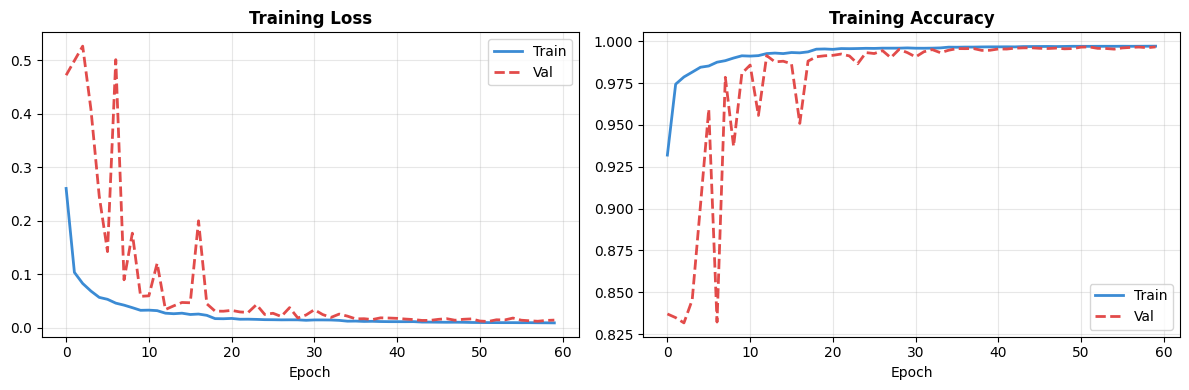

In [7]:
# ==================== TRAINING CURVES ====================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ["loss","accuracy"], ["Loss","Accuracy"]):
    ax.plot(history.history[metric], label="Train", linewidth=2, color="#3B8BD4")
    ax.plot(history.history[f"val_{metric}"], label="Val", linestyle="--", linewidth=2, color="#E24B4A")
    ax.set_title(f"Training {title}", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "lcga_training_history.png"), dpi=150)
plt.show()

In [8]:
# ==================== EVALUATION ====================
probs = lcga.predict(X_te_3d, verbose=0)
y_pred_lcga = np.argmax(probs, axis=1)

macro_f1  = f1_score(y_te, y_pred_lcga, average="macro", zero_division=0)
weight_f1 = f1_score(y_te, y_pred_lcga, average="weighted", zero_division=0)
acc       = accuracy_score(y_te, y_pred_lcga)
mcc       = matthews_corrcoef(y_te, y_pred_lcga)

print("="*60)
print(f"  LCGA Test Results")
print("="*60)
print(f"  Accuracy:     {acc:.4f}")
print(f"  Macro F1:     {macro_f1:.4f}")
print(f"  Weighted F1:  {weight_f1:.4f}")
print(f"  MCC:          {mcc:.4f}")
print(f"  Params:       {lcga.count_params():,}")
print(f"  Train time:   {train_time:.1f}s")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_te, y_pred_lcga, target_names=class_names, zero_division=0))

  LCGA Test Results
  Accuracy:     0.9967
  Macro F1:     0.8170
  Weighted F1:  0.9967
  MCC:          0.9889
  Params:       41,260
  Train time:   5391.2s

Classification Report:
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    419012
             Bot       0.60      0.62      0.61       389
            DDoS       1.00      1.00      1.00     25603
   DoS GoldenEye       0.98      0.94      0.96      2057
        DoS Hulk       1.00      0.99      0.99     34570
DoS Slowhttptest       0.85      0.98      0.91      1045
   DoS slowloris       0.97      0.88      0.92      1077
     FTP-Patator       0.99      0.99      0.99      1186
      Heartbleed       0.17      0.50      0.25         2
    Infiltration       0.14      0.86      0.24         7
        PortScan       0.99      1.00      0.99     18139
     SSH-Patator       1.00      0.90      0.95       644

        accuracy                           1.00    503731
   

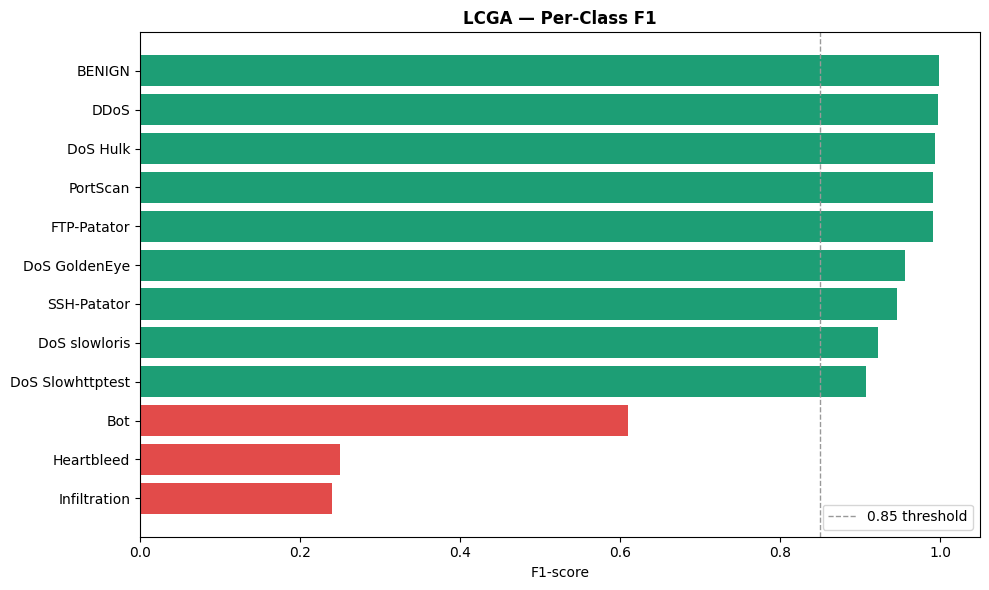

In [9]:
# ==================== PER‑CLASS F1 ====================
per_class_f1 = f1_score(y_te, y_pred_lcga, average=None, zero_division=0)
idxs = np.argsort(per_class_f1)
colors = ["#E24B4A" if f < 0.85 else "#1D9E75" for f in per_class_f1[idxs]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([class_names[i] for i in idxs], per_class_f1[idxs], color=colors)
ax.axvline(0.85, color="#999", linestyle="--", linewidth=1, label="0.85 threshold")
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1‑score"); ax.set_title("LCGA — Per‑Class F1", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "lcga_per_class_f1.png"), dpi=150)
plt.show()

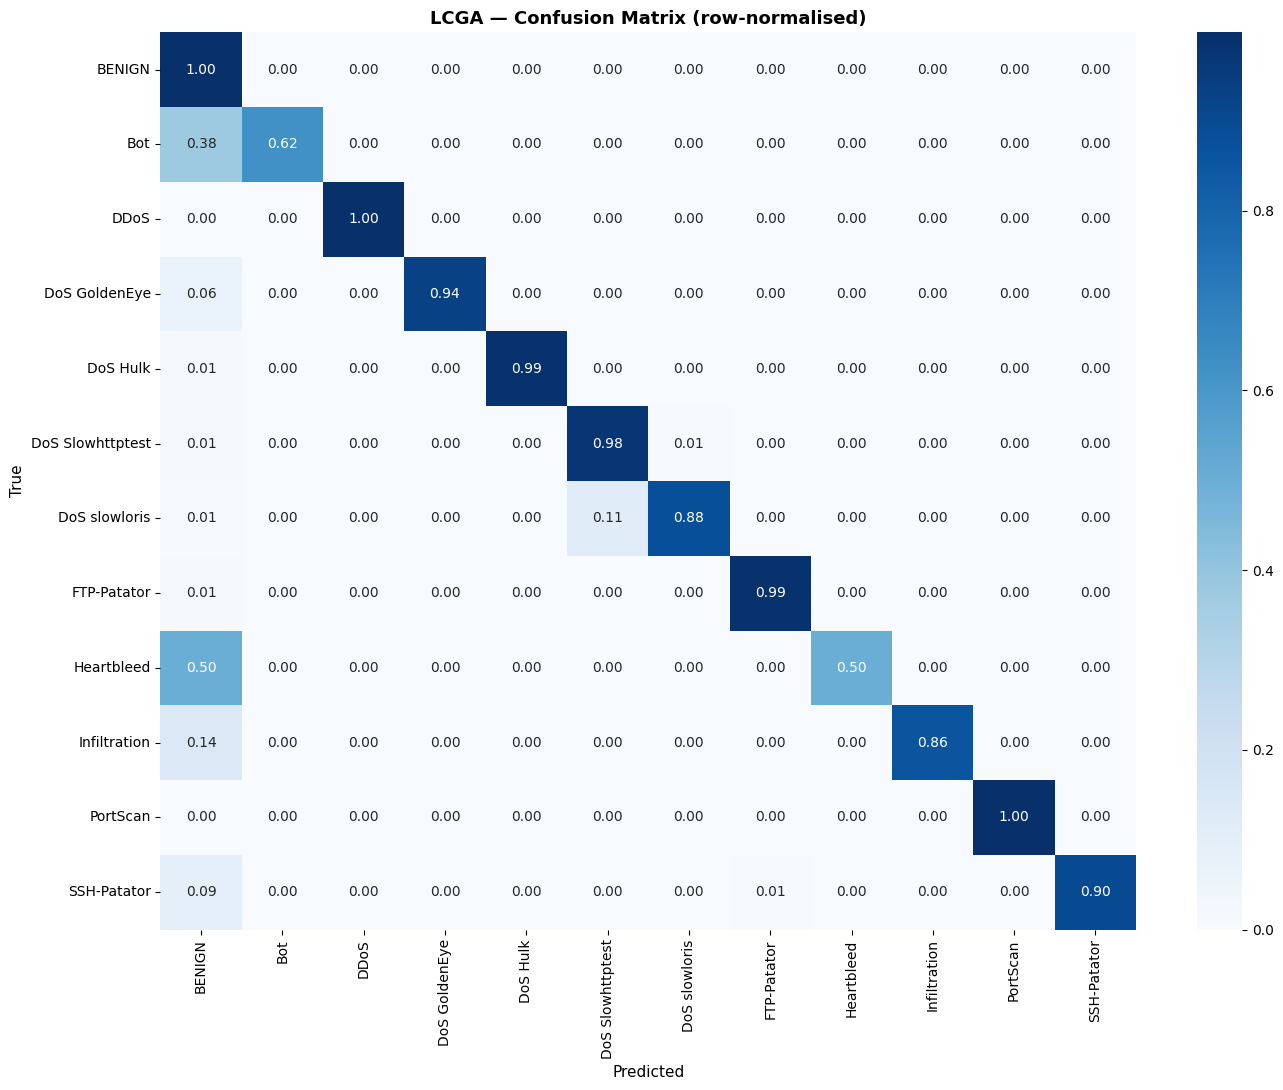

In [10]:
# ==================== CONFUSION MATRIX ====================
cm = confusion_matrix(y_te, y_pred_lcga)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted", fontsize=11); ax.set_ylabel("True", fontsize=11)
ax.set_title("LCGA — Confusion Matrix (row‑normalised)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "lcga_confusion_matrix.png"), dpi=150)
plt.show()

In [11]:
# ==================== INFERENCE LATENCY ====================
with tf.device("/CPU:0"):
    times = []
    single = X_te_3d[:1]
    for _ in range(500):
        t0 = time.perf_counter()
        lcga(single, training=False)
        times.append((time.perf_counter() - t0) * 1000)

lcga_lat = np.mean(times[50:])  # skip warmup
print(f"CPU Inference Latency: {lcga_lat:.2f} ms/sample (mean of 450 runs)")

CPU Inference Latency: 33.85 ms/sample (mean of 450 runs)



===== Model Comparison =====
        Model  Accuracy  Macro F1  Weighted F1      MCC    Params Train (s) Infer (ms)
Random Forest  0.998448  0.952683     0.998455 0.994815 100 trees     349.2      33.33
 CNN baseline  0.962305  0.639507     0.960005 0.869740     5,196    1642.5       3.76
 GRU baseline  0.998172  0.906989     0.998268 0.993914    17,804   13806.9     230.55
  LCGA (ours)  0.996695  0.816979     0.996731 0.988948    41,260    5391.2      33.85


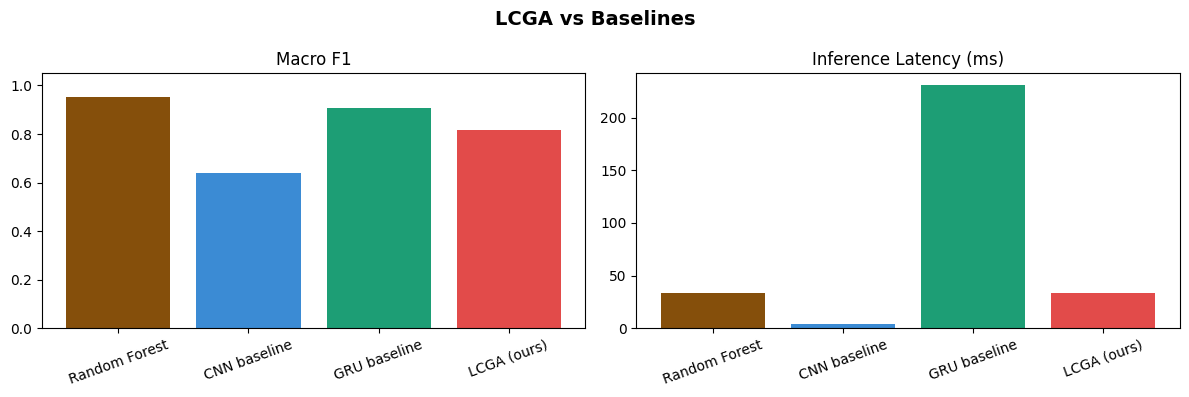

In [14]:
# ==================== COMPARISON WITH BASELINES ====================
# Load baseline results from Notebook 02 output
baselines_path = "/kaggle/input/notebooks/getayefiseha/notebook-02-baseline-models/results/baselines_cicids.csv"
baselines_df = pd.read_csv(baselines_path)

# Create LCGA row
lcga_row = {
    "Model": "LCGA (ours)",
    "Accuracy": acc,
    "Macro F1": macro_f1,
    "Weighted F1": weight_f1,
    "MCC": mcc,
    "Params": f"{lcga.count_params():,}",
    "Train (s)": f"{train_time:.1f}",
    "Infer (ms)": f"{lcga_lat:.2f}",
}
comparison_df = pd.concat([baselines_df, pd.DataFrame([lcga_row])], ignore_index=True)

print("\n===== Model Comparison =====")
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(RES_DIR, "model_comparison.csv"), index=False)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models_names = comparison_df["Model"].tolist()
f1s  = comparison_df["Macro F1"].tolist()
lats = [float(x) for x in comparison_df["Infer (ms)"].tolist()]
colors = ["#854F0B","#3B8BD4","#1D9E75","#E24B4A"]

axes[0].bar(models_names, f1s, color=colors); axes[0].set_title("Macro F1"); axes[0].set_ylim(0,1.05)
axes[1].bar(models_names, lats, color=colors); axes[1].set_title("Inference Latency (ms)")
for ax in axes: ax.tick_params(axis="x", rotation=20)
plt.suptitle("LCGA vs Baselines", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "lcga_vs_baselines.png"), dpi=150)
plt.show()

In [15]:
# ==================== SAVE MODEL & RESULTS ====================
lcga.save(os.path.join(MODEL_DIR, "lcga_cicids.keras"))
print("✓ LCGA model saved")

# Save metrics as JSON
lcga_metrics = {
    "Model": "LCGA",
    "Accuracy": float(acc),
    "Macro_F1": float(macro_f1),
    "Weighted_F1": float(weight_f1),
    "MCC": float(mcc),
    "Params": lcga.count_params(),
    "Train_time_s": float(train_time),
    "Infer_latency_ms": float(lcga_lat),
}
with open(os.path.join(RES_DIR, "lcga_metrics.json"), "w") as f:
    json.dump(lcga_metrics, f, indent=2)
print("✓ Metrics saved")

✓ LCGA model saved
✓ Metrics saved


# # ✅ LCGA Training Complete!
# 
# **Saved**:
# - `models/lcga_cicids.keras` — trained LCGA model
# - `models/lcga_best.keras` — best checkpoint (early stopping)
# - `results/lcga_metrics.json` — quantitative metrics
# - `results/lcga_training_history.png` — loss/accuracy curves
# - `results/lcga_per_class_f1.png` — per‑class F1 bar chart
# - `results/lcga_confusion_matrix.png` — confusion matrix
# - `results/lcga_vs_baselines.png` — comparison plot
# - `results/model_comparison.csv` — full comparison table
# 
# **Next → Notebook 04: DT Surrogate + SHAP Explainability**